In [2]:
import pandas as pd

from protest_impact.util import project_root

count_df = pd.read_csv(
    project_root / "data" / "protest" / "protest_and_topic_counts.csv"
)
count_df["date"] = pd.to_datetime(count_df["date"])
count_df.head()

,date,topic,count,type,media_id,name,keyword
0,2014-01-03,feminism,1,protest,NaN,NaN,NaN
1,2014-01-03,labour,1,protest,NaN,NaN,NaN
2,2014-01-03,racism,1,protest,NaN,NaN,NaN
3,2014-01-03,yellow jackets,1,protest,NaN,NaN,NaN
4,2014-01-04,anti-war,1,protest,NaN,NaN,NaN


In [12]:
topic_count_df = count_df.copy()[count_df["type"] == "general"]
topic_count_df["count"] = topic_count_df.groupby(["date", "media_id", "name"])[
    "count"
].transform(lambda x: x / x.sum())
topic_count_df.head()

,date,topic,count,type,media_id,name,keyword
14970,2010-01-09,feminism,1.0,general,119705.0,kreiszeitung.de,frau*
14971,2010-02-08,covid,0.5,general,69752.0,augsburger-allgemeine.de,impf*
14972,2010-02-08,feminism,0.5,general,69752.0,augsburger-allgemeine.de,frau*
14973,2010-03-01,racism,1.0,general,144263.0,bz-berlin.de,rassis*
14974,2010-03-09,feminism,0.5,general,69752.0,augsburger-allgemeine.de,frau*


In [13]:
from itertools import product
from multiprocessing import Pool

import numpy as np

# grid search with itertools
from tqdm.notebook import tqdm

from protest_impact.data.discourse.get_counts import get_topic_counts

df = pd.DataFrame()
with Pool(1) as p:
    for df_ in tqdm(
        p.imap_unordered(
            get_topic_counts,
            list(
                product(
                    list(count_df["keyword"].unique()),
                    list(count_df["media_id"].unique()),
                    [2],
                    [32],
                )
            )[:10],
        ),
        total=len(count_df["keyword"].unique()) * len(count_df["media_id"].unique()),
    ):
        if df_ is not None:
            df = pd.concat([df, df_], axis=0)


df.to_csv(project_root / "data" / "protest" / "topic_association.csv", index=False)

df.head()

  0%|          | 0/4888 [00:00<?, ?it/s]

""


In [14]:
from dateutil.relativedelta import relativedelta

from protest_impact.util import project_root


def get_topic_counts(keyword, media_id, inner_distance, outer_distance):
    # retrieve topic of keyword
    keyword_rows = count_df[count_df["keyword"] == keyword]["topic"]
    if len(keyword_rows) == 0:
        print(keyword)
        print(count_df[count_df["keyword"] == keyword]["topic"])
        return None
    topic = keyword_rows.iloc[0]
    protest_counts = count_df[
        (count_df["type"] == "protest")
        & (count_df["topic"] == topic)
        & (count_df.date.dt.year >= 2014)
        & (count_df.date.dt.year <= 2021)
    ].copy()
    topic_count_df_ = topic_count_df[
        (topic_count_df.media_id == media_id) & (topic_count_df.keyword == keyword)
    ].copy()
    protest_counts["past_start"] = protest_counts["date"].apply(
        lambda x: x - relativedelta(days=outer_distance)
    )
    protest_counts["past_end"] = protest_counts["date"].apply(
        lambda x: x - relativedelta(days=inner_distance)
    )
    protest_counts["future_start"] = protest_counts["date"].apply(
        lambda x: x + relativedelta(days=inner_distance)
    )
    protest_counts["future_end"] = protest_counts["date"].apply(
        lambda x: x + relativedelta(days=outer_distance)
    )
    protest_counts["past_count"] = protest_counts.apply(
        lambda x: topic_count_df_[
            (topic_count_df_.date >= x["past_start"])
            & (topic_count_df_.date <= x["past_end"])
        ]["count"].sum(),
        axis=1,
    )
    protest_counts["future_count"] = protest_counts.apply(
        lambda x: topic_count_df_[
            (topic_count_df_.date >= x["future_start"])
            & (topic_count_df_.date <= x["future_end"])
        ]["count"].sum(),
        axis=1,
    )
    protest_counts["keyword"] = keyword
    protest_counts["topic"] = topic
    protest_counts["media_id"] = media_id
    # name of newspaper
    # protest_counts["name"] = protest_counts["media_id"].apply(
    protest_counts["inner_distance"] = inner_distance
    protest_counts["outer_distance"] = outer_distance
    return protest_counts


from itertools import product

# grid search with itertools
from tqdm.notebook import tqdm

df = pd.DataFrame()
for keyword, media_id, inner_distance, outer_distance in tqdm(
    list(
        product(
            list(count_df["keyword"].unique())[1:],
            list(count_df["media_id"].unique()),
            [2],
            [32],
        )
    )[:50],
):
    df_ = get_topic_counts(keyword, media_id, inner_distance, outer_distance)
    df = pd.concat([df, df_], axis=0)

  0%|          | 0/50 [00:00<?, ?it/s]

In [15]:
len(df)

55100

In [16]:
df.head()

,date,topic,count,type,media_id,name,keyword,past_start,past_end,future_start,future_end,past_count,future_count,inner_distance,outer_distance
0,2014-01-03,feminism,1,protest,NaN,NaN,frau*,2013-12-02,2014-01-01,2014-01-05,2014-02-04,0.0,0.0,2,32
5,2014-01-04,feminism,1,protest,NaN,NaN,frau*,2013-12-03,2014-01-02,2014-01-06,2014-02-05,0.0,0.0,2,32
21,2014-01-28,feminism,1,protest,NaN,NaN,frau*,2013-12-27,2014-01-26,2014-01-30,2014-03-01,0.0,0.0,2,32
31,2014-02-14,feminism,1,protest,NaN,NaN,frau*,2014-01-13,2014-02-12,2014-02-16,2014-03-18,0.0,0.0,2,32
32,2014-02-21,feminism,1,protest,NaN,NaN,frau*,2014-01-20,2014-02-19,2014-02-23,2014-03-25,0.0,0.0,2,32


In [4]:
len(list(count_df["media_id"].unique()))

52

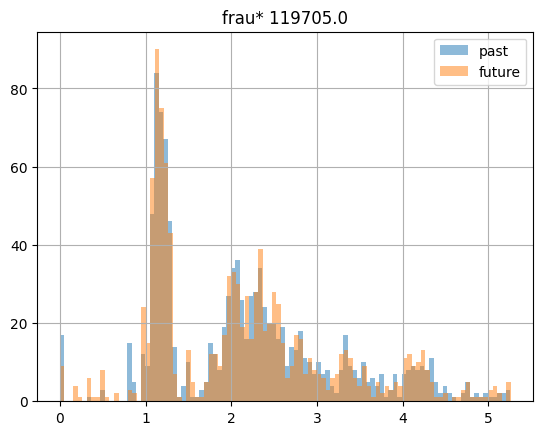

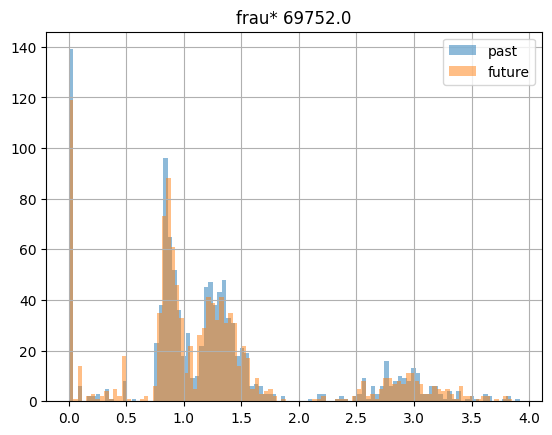

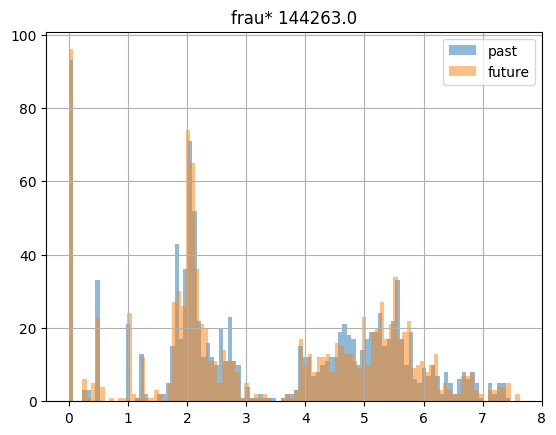

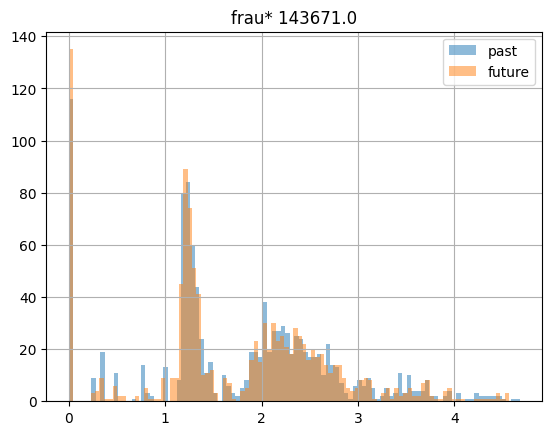

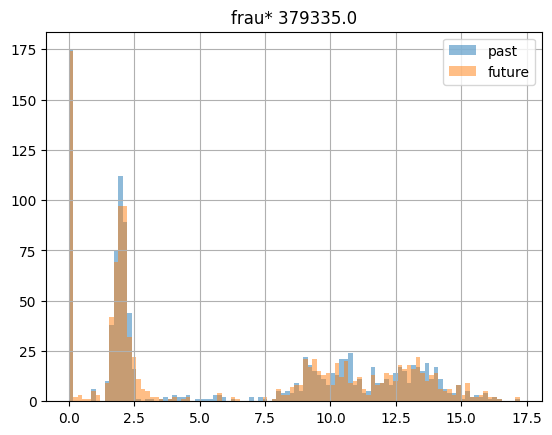

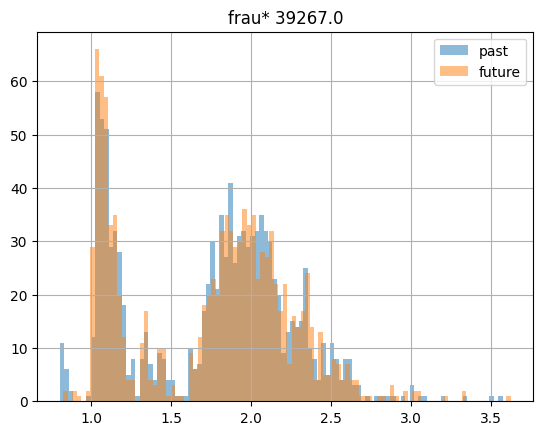

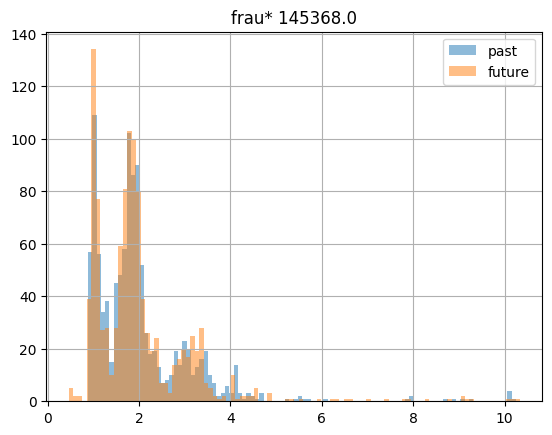

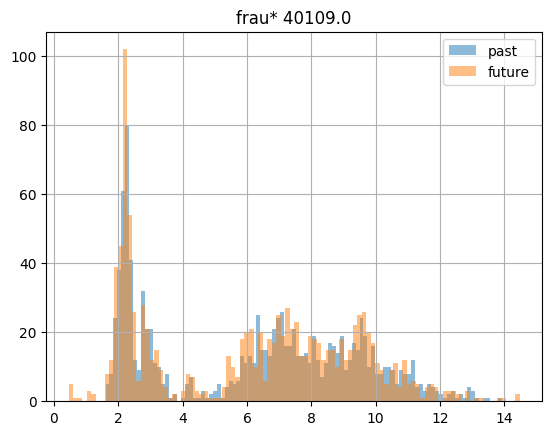

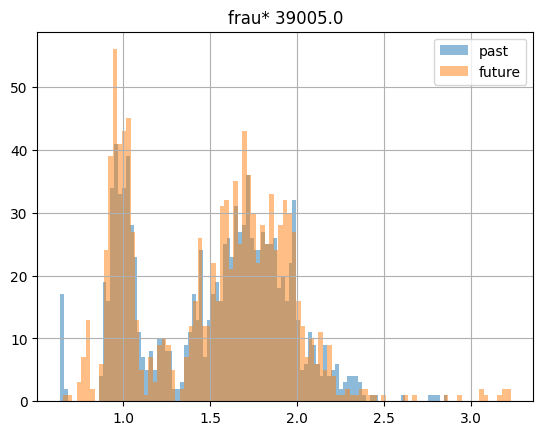

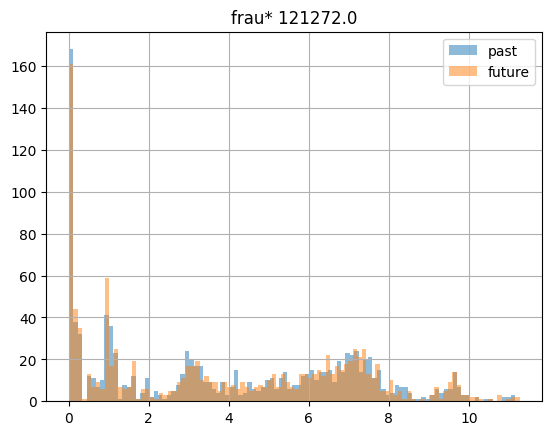

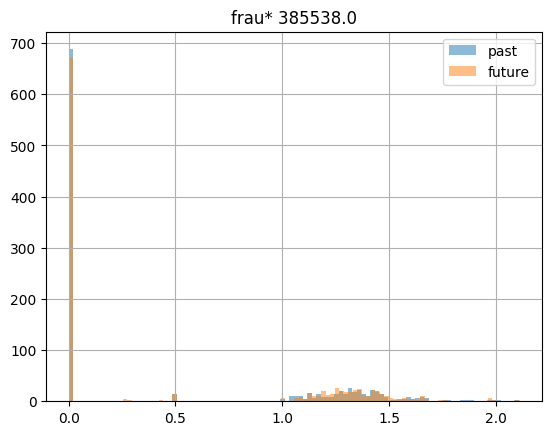

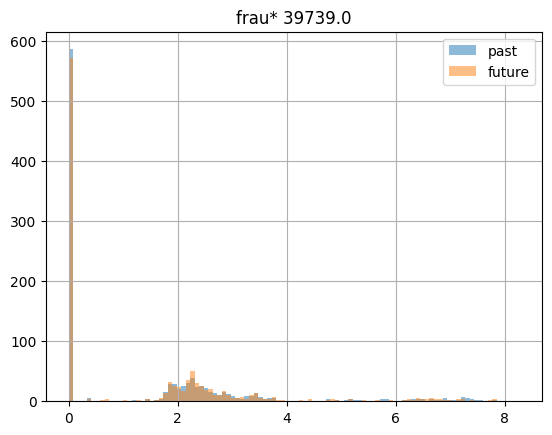

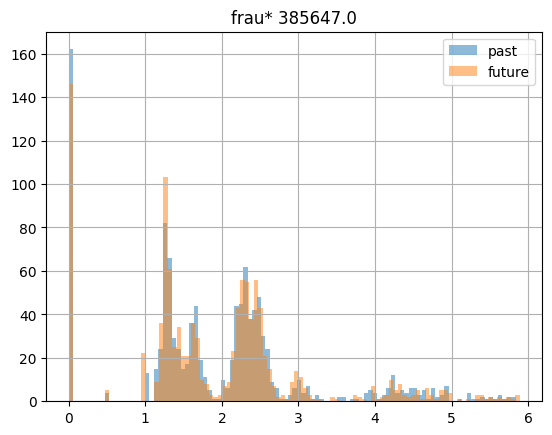

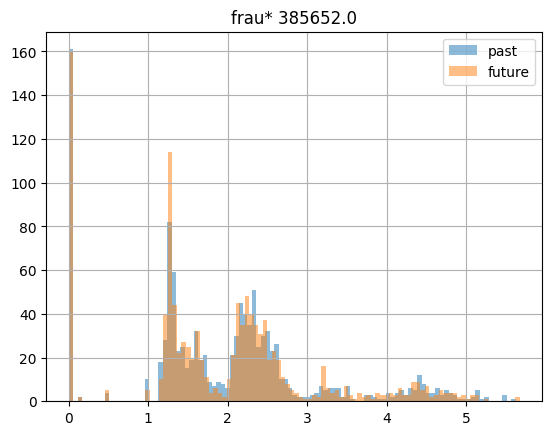

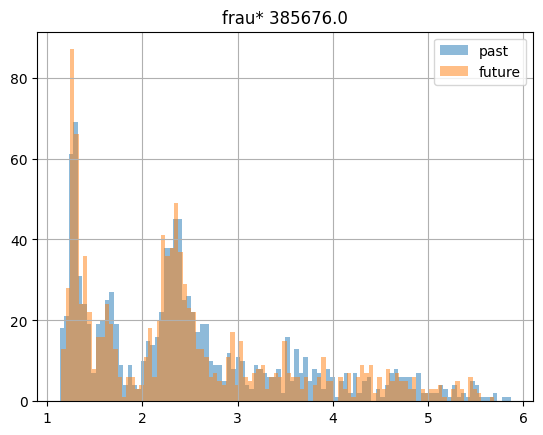

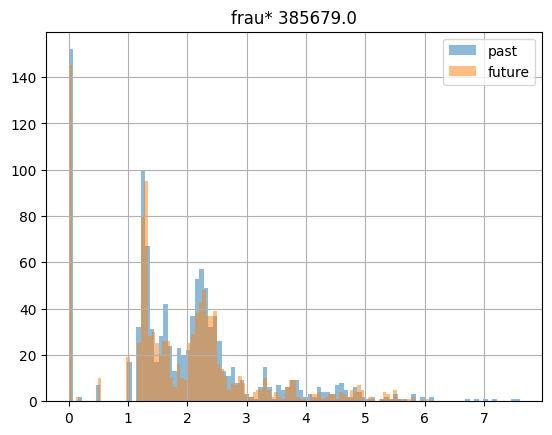

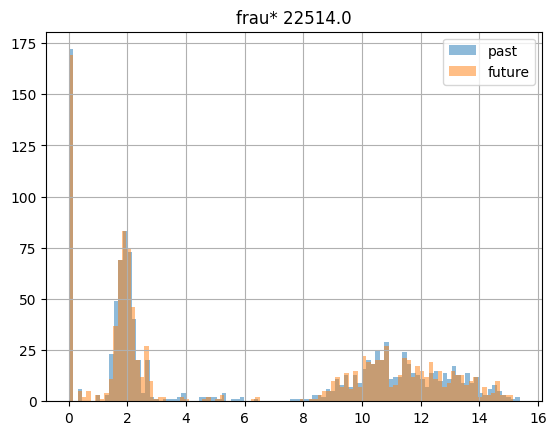

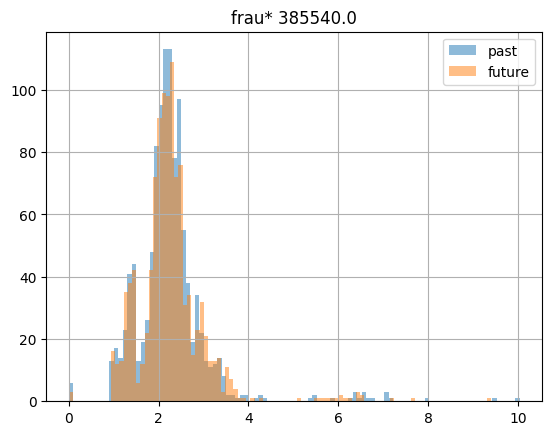

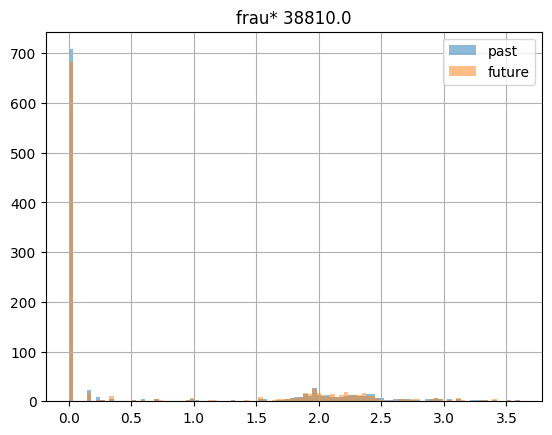

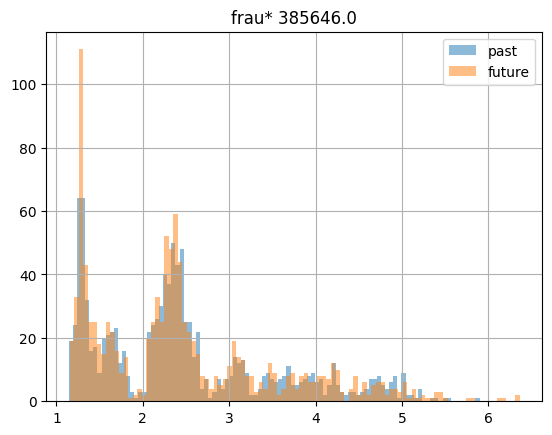

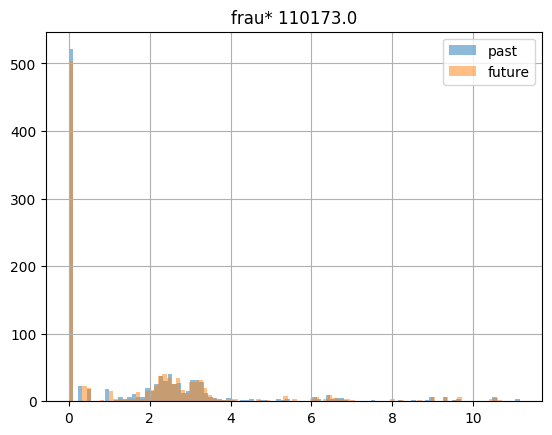

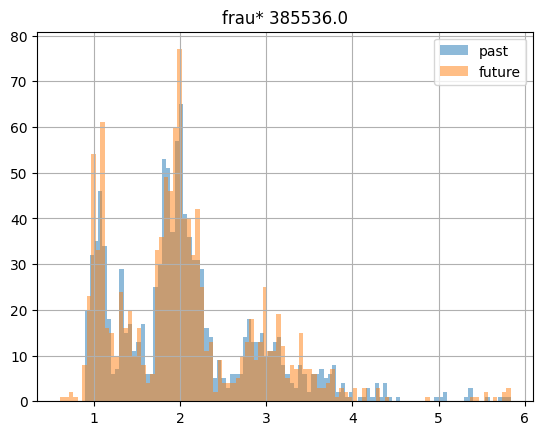

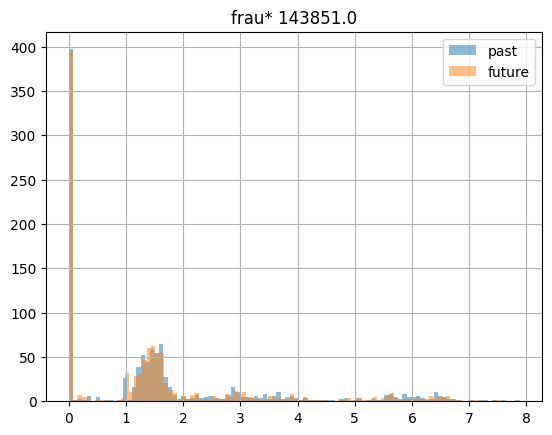

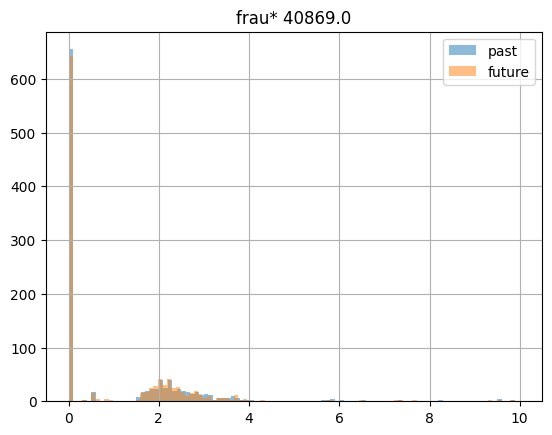

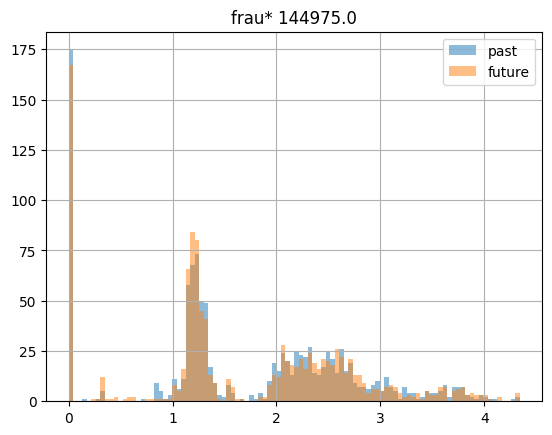

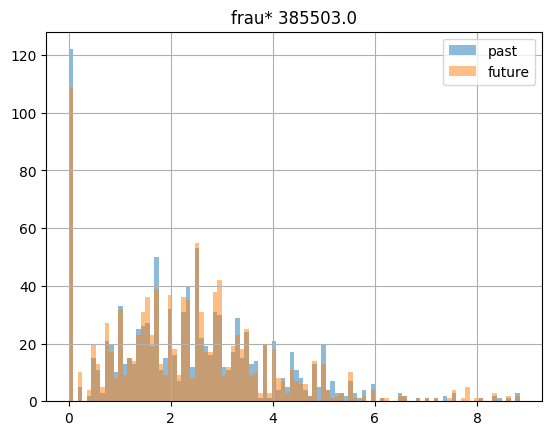

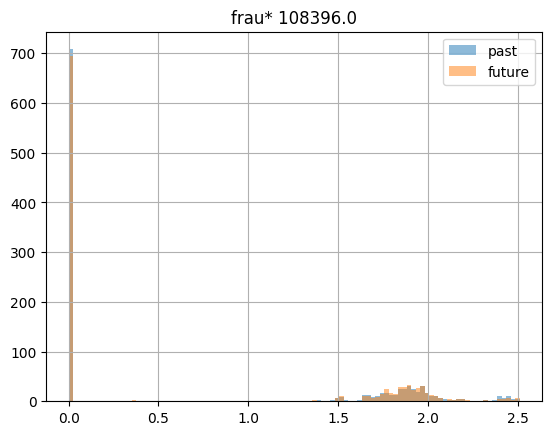

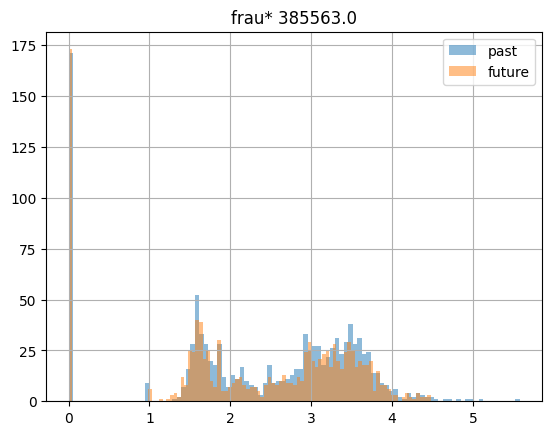

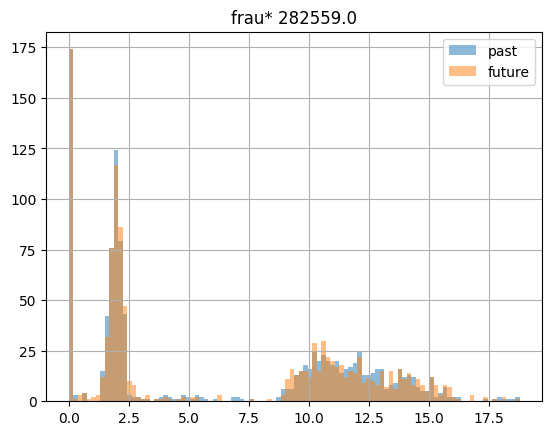

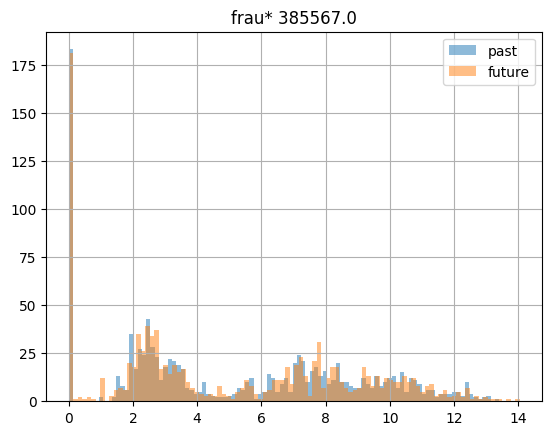

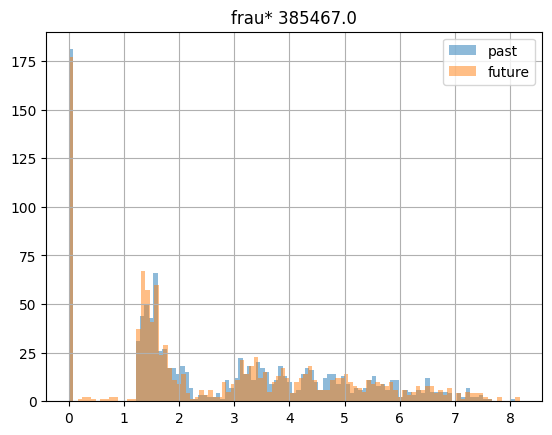

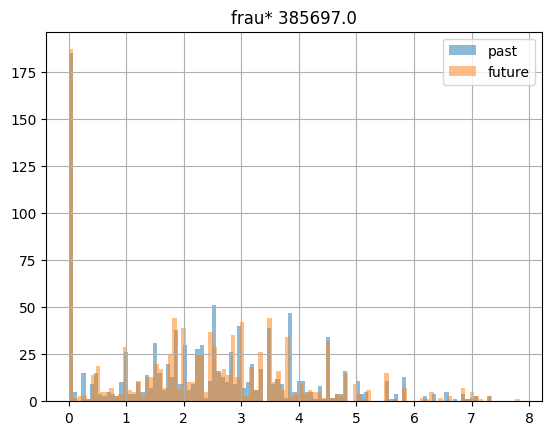

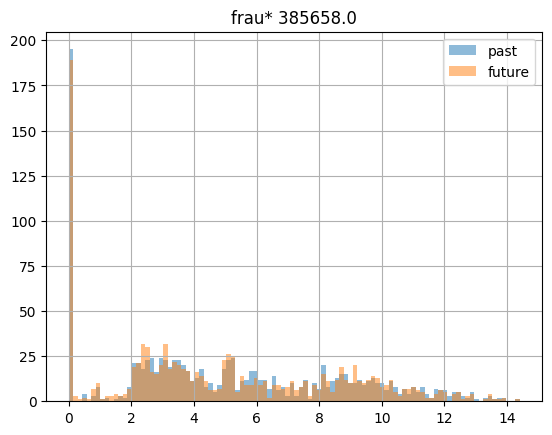

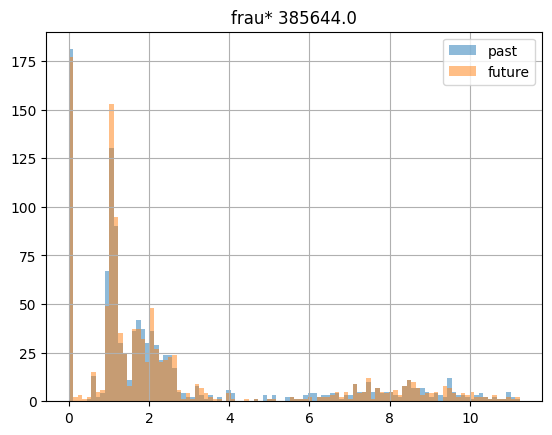

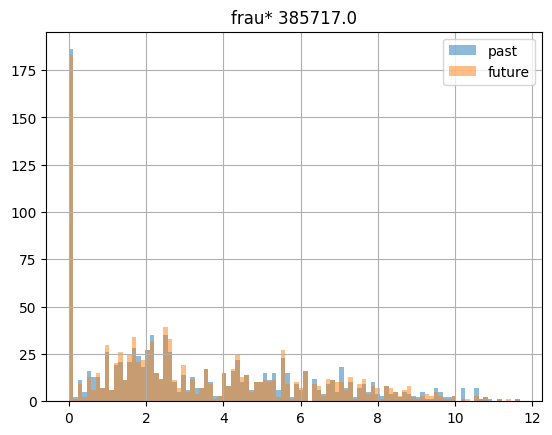

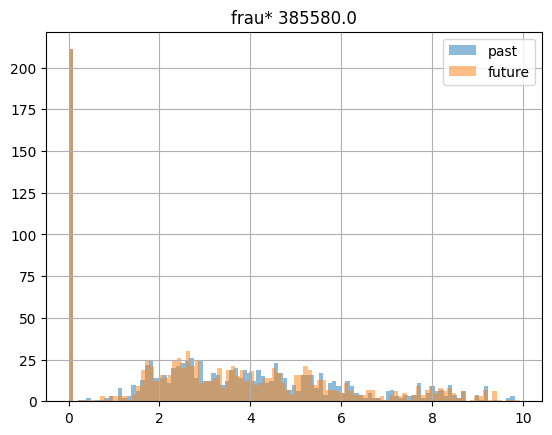

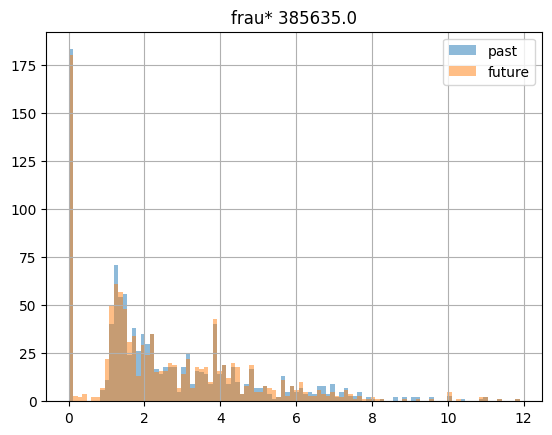

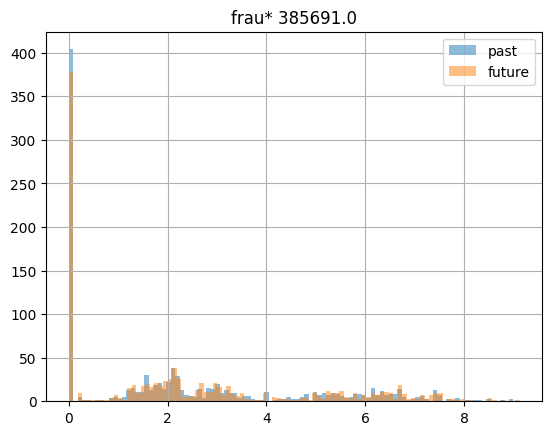

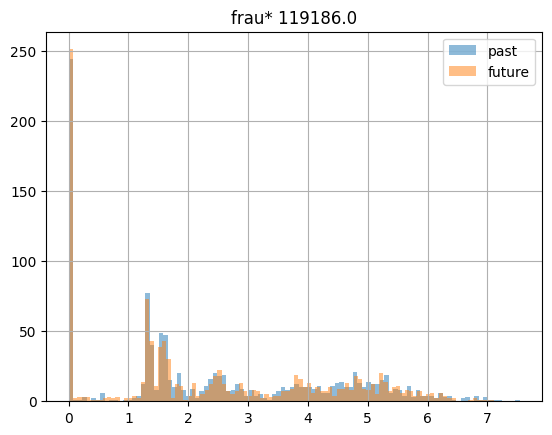

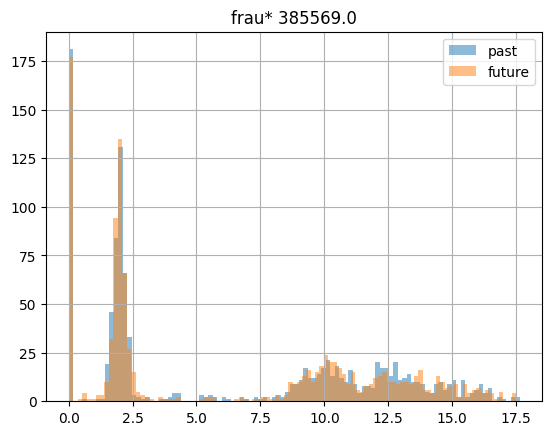

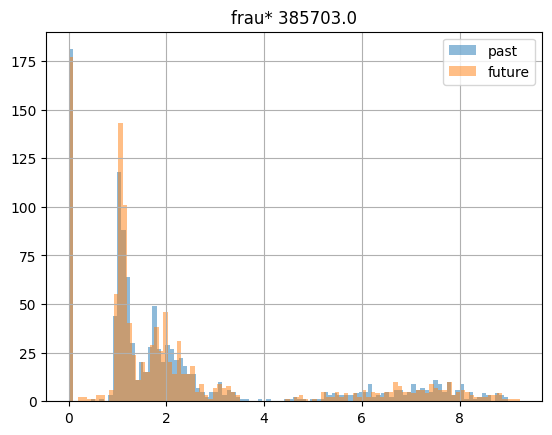

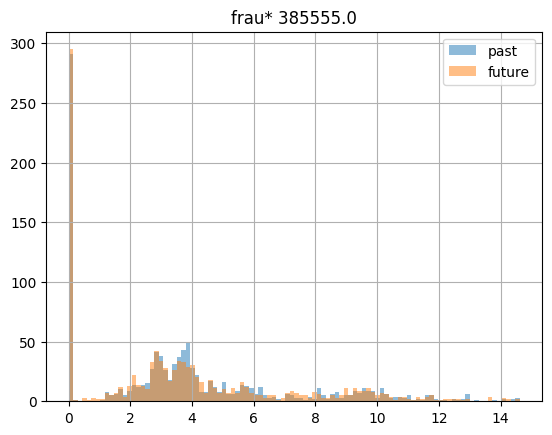

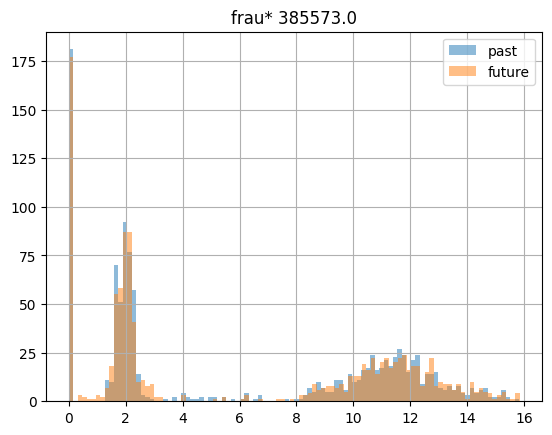

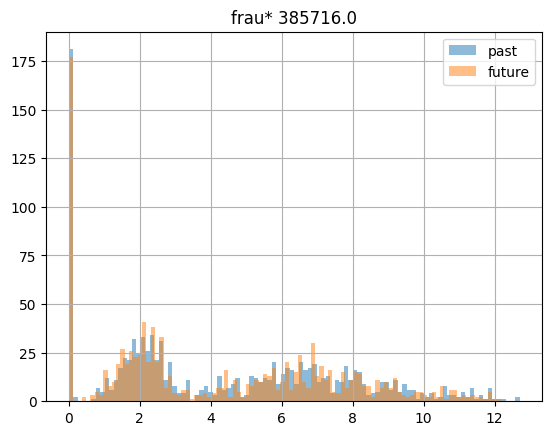

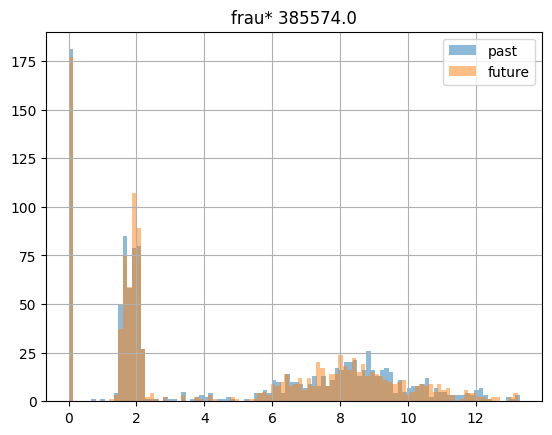

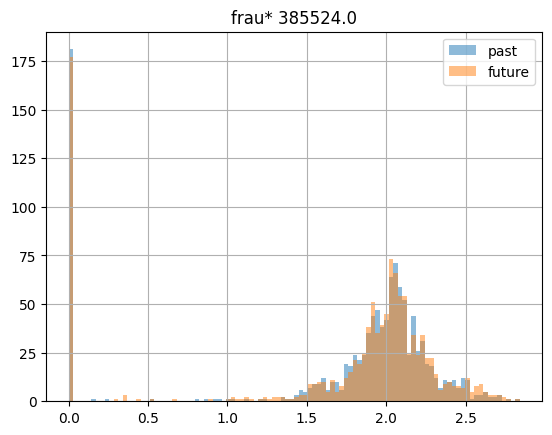

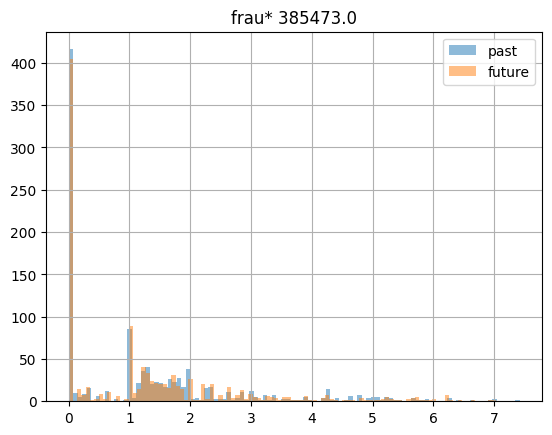

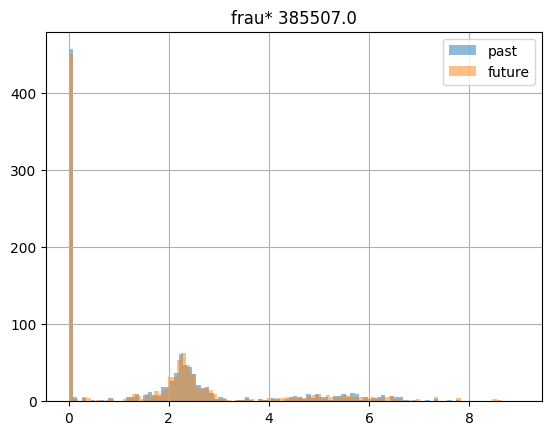

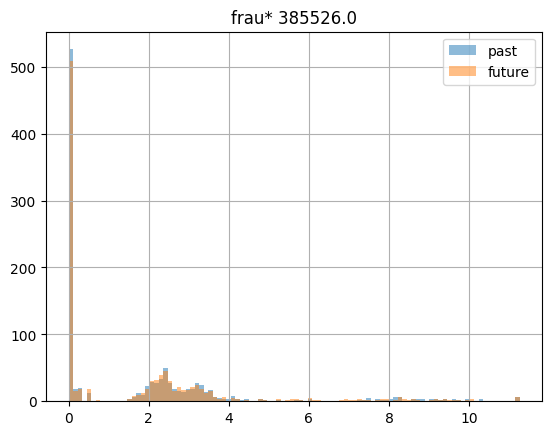

In [20]:
import matplotlib.pyplot as plt

for keyword in df["keyword"].unique():
    for newspaper in df["media_id"].unique():
        df_ = df[(df["keyword"] == keyword) & (df["media_id"] == newspaper)]
        if len(df_) > 0:
            df_["past_count"].hist(bins=100, alpha=0.5, label="past")
            df_["future_count"].hist(bins=100, alpha=0.5, label="future")
            plt.title(f"{keyword} {newspaper}")
            plt.legend()
            plt.show()

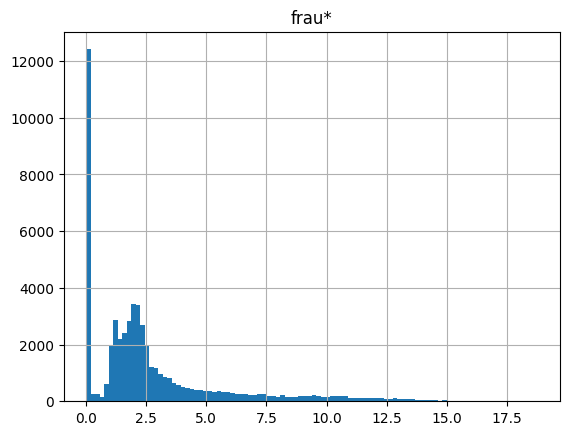

In [19]:
for keyword in df["keyword"].unique():
    df_ = df[df["keyword"] == keyword]
    df_["past_count"].hist(bins=100)
    plt.title(keyword)
    plt.show()

In [ ]:
import numpy as np

df["log_change"] = df["change"].apply(lambda x: np.log2(x))
df["log_change"].hist(bins=100)

In [ ]:
df["log_change"].describe()

In [ ]:
df.to_csv(project_root / "data" / "protest" / "topic_changes.csv", index=False)

In [ ]:
stats = []
for topic in df["topic"].unique():
    stats.append(
        {
            "topic": topic,
            "mean": df[df["topic"] == topic]["log_change"].mean(),
            "std": df[df["topic"] == topic]["log_change"].std(),
        }
    )
stats_df = pd.DataFrame(stats)
stats_df

In [ ]:
stats_df.hist(bins=10)